In [ ]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import random
import os

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load dataset

file_path = "/content/AIS Dataset on Cloud DDoS Attacks (1).csv"
df = pd.read_csv(file_path)

In [ ]:
# Basic preview
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset: (52318, 80)

First 5 rows:


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound,label
0,52380,443,6,1,2,0,0,0,0,0,...,0.000000e+00,0.000000e+00,0,0,0.000000e+00,0.000000e+00,0,0,0,BENIGN
1,443,52380,6,2,3,0,62,0,31,0,...,0.000000e+00,0.000000e+00,0,0,0.000000e+00,0.000000e+00,0,0,1,BENIGN
2,443,52380,6,218,1,2,0,0,0,0,...,0.000000e+00,0.000000e+00,0,0,0.000000e+00,0.000000e+00,0,0,1,BENIGN
3,0,0,0,115366430,52,0,0,0,0,0,...,6.666667e+00,1.073087e+00,8,4,9.613862e+06,2.884856e+05,9988327,9110910,0,BENIGN
4,68,67,17,109157387,16,0,4800,0,300,300,...,5.929966e+06,3.774939e+06,10054849,2647210,1.015194e+07,2.795046e+06,14600796,6304546,0,BENIGN



Column names:
[' Source Port', ' Destination Port', ' Protocol', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' 

In [ ]:
# Fix column names
df.columns = df.columns.str.strip()
print("Cleaned Column Names:\n", df.columns.tolist())
# Columns Data types
df.dtypes

Cleaned Column Names:
 ['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count',

,0
Source Port,int64
Destination Port,int64
Protocol,int64
Flow Duration,int64
Total Fwd Packets,int64
...,...
Idle Std,float64
Idle Max,int64
Idle Min,int64
Inbound,int64


In [ ]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

print("\nMissing Values:")
print(missing if len(missing) > 0 else "No missing values")


Missing Values:
No missing values


In [ ]:
# Duplicate check
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)


Number of duplicate rows: 761


In [ ]:
#  Remove duplicates
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (51557, 80)


### EDA

In [ ]:
# Check target column
print("\nTarget column unique values:")
print(df["label"].value_counts())

# Check class distribution
print("\nClass distribution (%):")
print(df["label"].value_counts(normalize=True) * 100)


Target column unique values:
label
DDOS      26887
BENIGN    24670
Name: count, dtype: int64

Class distribution (%):
label
DDOS      52.150048
BENIGN    47.849952
Name: proportion, dtype: float64


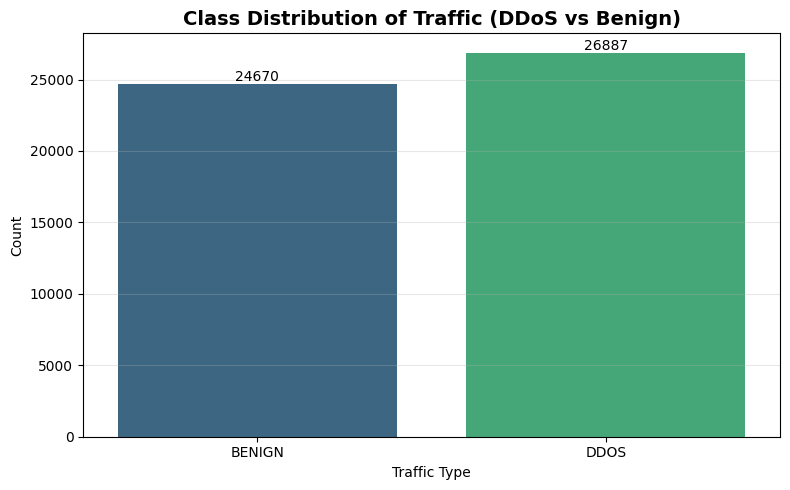

In [ ]:
#  Class Distribution
plt.figure(figsize=(8,5))
sns.countplot(
    x="label",
    data=df,
    palette="viridis"
)

plt.title("Class Distribution of Traffic (DDoS vs Benign)", fontsize=14, weight="bold")
plt.xlabel("Traffic Type")
plt.ylabel("Count")

# Value labels on bars
for p in plt.gca().patches:
    height = p.get_height()
    plt.text(
        p.get_x() + p.get_width()/2,
        height + 200,
        f"{int(height)}",
        ha="center",
        fontsize=10
    )

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Packet Length Mean vs Class

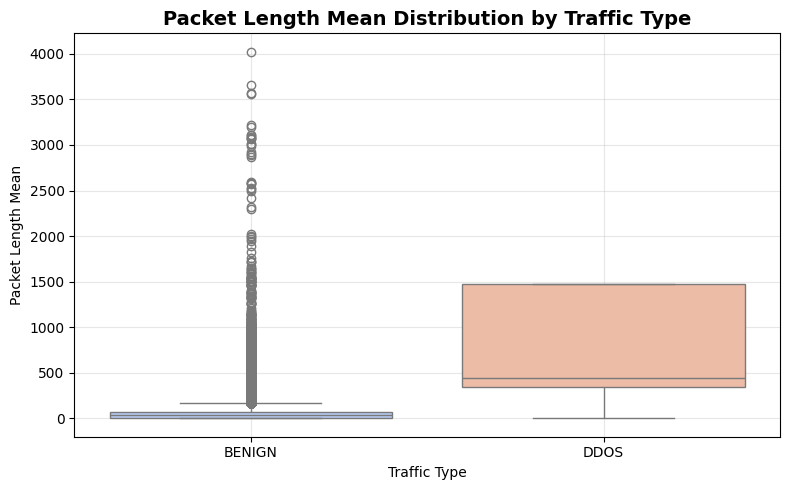

In [ ]:
# Packet Length Mean vs Class
plt.figure(figsize=(8,5))
sns.boxplot(
    x="label",
    y="Packet Length Mean",
    data=df,
    palette="coolwarm"
)

plt.title("Packet Length Mean Distribution by Traffic Type", fontsize=14, weight="bold")
plt.xlabel("Traffic Type")
plt.ylabel("Packet Length Mean")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

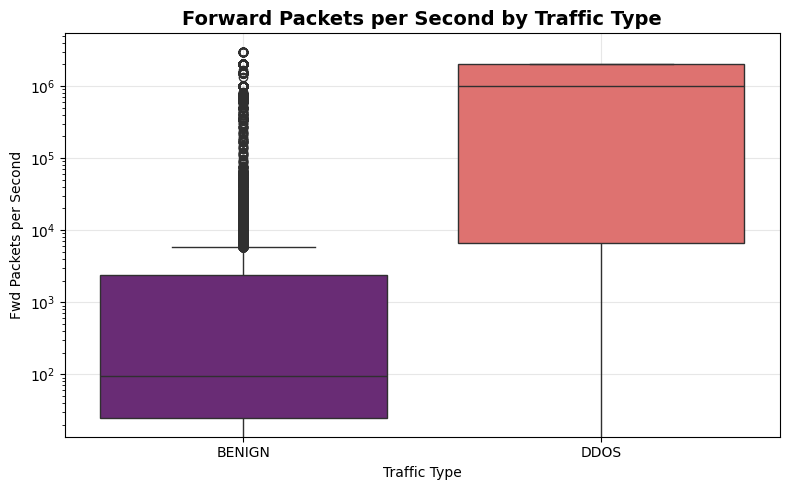

In [ ]:
# Packets per second comparison

plt.figure(figsize=(8,5))
sns.boxplot(
    x="label",
    y="Fwd Packets/s",
    data=df,
    palette="magma"
)

plt.title("Forward Packets per Second by Traffic Type", fontsize=14, weight="bold")
plt.xlabel("Traffic Type")
plt.ylabel("Fwd Packets per Second")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

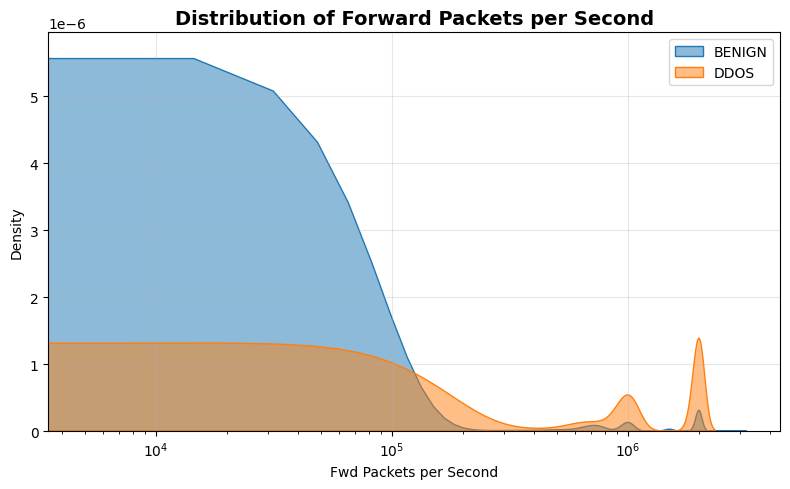

In [ ]:
#  Fwd Packets

plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df[df["label"] == "BENIGN"],
    x="Fwd Packets/s",
    fill=True,
    label="BENIGN",
    alpha=0.5
)

sns.kdeplot(
    data=df[df["label"] == "DDOS"],
    x="Fwd Packets/s",
    fill=True,
    label="DDOS",
    alpha=0.5
)

plt.xscale("log")
plt.title("Distribution of Forward Packets per Second", fontsize=14, weight="bold")
plt.xlabel("Fwd Packets per Second")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Flow Duration Distribution (Attack Timing Behavior)

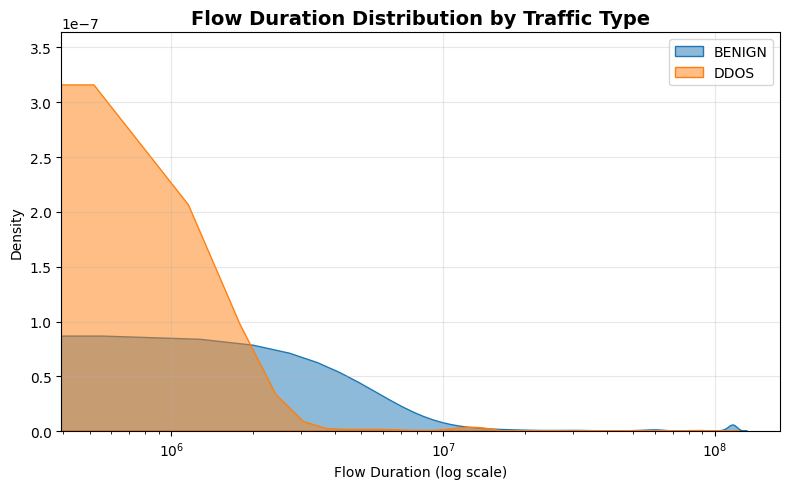

In [ ]:
# Flow Duration Distribution

plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df[df["label"] == "BENIGN"],
    x="Flow Duration",
    fill=True,
    label="BENIGN",
    alpha=0.5
)

sns.kdeplot(
    data=df[df["label"] == "DDOS"],
    x="Flow Duration",
    fill=True,
    label="DDOS",
    alpha=0.5
)

plt.xscale("log")

plt.title("Flow Duration Distribution by Traffic Type", fontsize=14, weight="bold")
plt.xlabel("Flow Duration (log scale)")
plt.ylabel("Density")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Top Correlated Features with Target:


,label_encoded
Inbound,0.828857
Min Packet Length,0.607869
Fwd Packet Length Min,0.606694
Avg Fwd Segment Size,0.599225
Fwd Packet Length Mean,0.599225
Packet Length Mean,0.563843
Average Packet Size,0.561039
Down/Up Ratio,0.559465
Fwd Packets/s,0.507838
URG Flag Count,0.500654


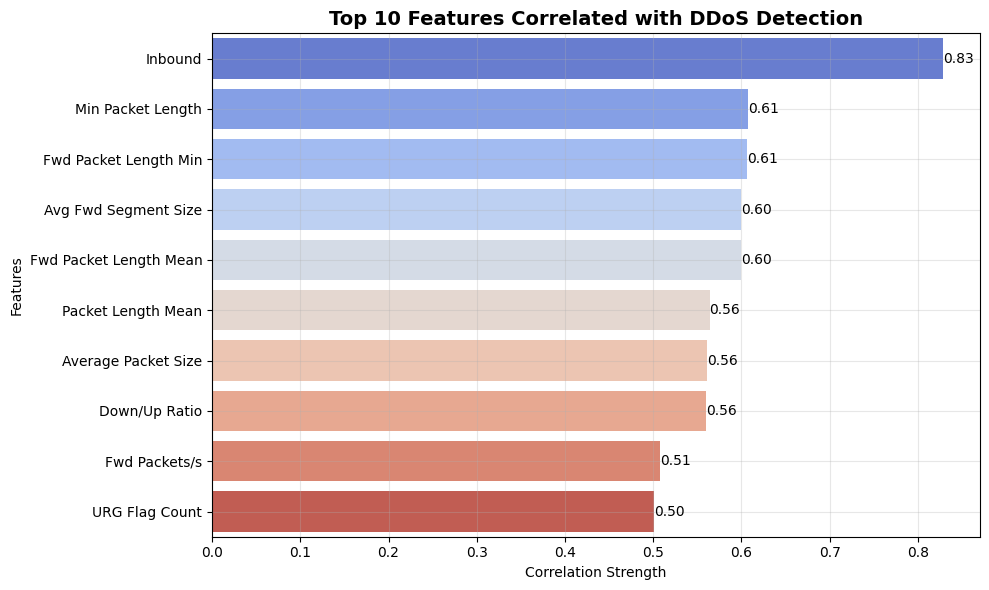

In [ ]:
# Correlation with target
# Encode target for correlation
df["label_encoded"] = df["label"].map({"BENIGN": 0, "DDOS": 1})

# Select numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation with target
corr_target = numeric_df.corr()["label_encoded"].drop("label_encoded")

# Sort by absolute correlation
corr_target = corr_target.abs().sort_values(ascending=False)

# Top 10 features
top_corr = corr_target.head(10)

print("Top Correlated Features with Target:")
display(top_corr)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index,
    palette="coolwarm"
)

plt.title("Top 10 Features Correlated with DDoS Detection", fontsize=14, weight="bold")
plt.xlabel("Correlation Strength")
plt.ylabel("Features")

# Value labels
for i, v in enumerate(top_corr.values):
    plt.text(v, i, f"{v:.2f}", va="center")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#  Final label encoding

# Convert target to numeric
df["label"] = df["label"].map({"BENIGN": 0, "DDOS": 1})

# Drop temporary column
df.drop(columns=["label_encoded"], inplace=True)

print("Label encoding done successfully")
print(df["label"].value_counts())

Label encoding done successfully
label
1    26887
0    24670
Name: count, dtype: int64


In [ ]:
# Multicollinearity check

# Select numeric features only
numeric_df = df.drop(columns=["label"])

# Correlation matrix
corr_matrix = numeric_df.corr().abs()

# Upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated pairs
high_corr = (
    upper.stack()
    .reset_index()
)

high_corr.columns = ["Feature 1", "Feature 2", "Correlation"]

# Filter
high_corr = high_corr[high_corr["Correlation"] > 0.8]

# Sort
high_corr = high_corr.sort_values(by="Correlation", ascending=False)

print("Highly Correlated Feature Pairs (>|0.8|):")
display(high_corr.head(20))

Highly Correlated Feature Pairs (>|0.8|):


,Feature 1,Feature 2,Correlation
303,Total Fwd Packets,Subflow Fwd Packets,1.000000
425,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000000
366,Total Backward Packets,Subflow Bwd Packets,1.000000
651,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000
486,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000000
866,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000
1555,Fwd PSH Flags,RST Flag Count,1.000000
1598,Fwd Header Length,Fwd Header Length.1,1.000000
583,Fwd Packet Length Min,Min Packet Length,0.998948
211,Flow Duration,Fwd IAT Total,0.997987


In [ ]:
df.shape

(51557, 80)

In [ ]:
# Drop multicollinear features automatically >0.80

numeric_df = df.drop(columns=["label"])

corr_matrix = numeric_df.corr().abs()

# Upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Columns to drop
to_drop = [col for col in upper.columns if any(upper[col] > 0.80)]
# Create cleaned dataset
df_clean = df.drop(columns=to_drop)

df_clean = df_clean.drop(columns=["Source Port", "Destination Port", "Inbound","Fwd Packet Length Max",
    "Down/Up Ratio","Bwd Packets/s", "Bwd Header Length","Total Backward Packets", "URG Flag Count","Bwd IAT Mean",
                                  "Bwd IAT Min","Fwd Packet Length Max", "Down/Up Ratio", "Fwd IAT Total", "Fwd IAT Min",
    "Total Length of Fwd Packets","Flow Duration", "Bwd Packet Length Mean", "min_seg_size_forward","Bwd Packet Length Max","Bwd Packet Length Min","Fwd Header Length"], errors="ignore")
print("\nNew shape after dropping:", df_clean.shape)


New shape after dropping: (51557, 28)


In [ ]:
# Train-test split + scaling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# X and y
X = df_clean.drop("label", axis=1)
y = df_clean["label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Decision Tree Model

Decision Tree Performance
Accuracy  : 81.85%
Precision : 92.78%
Recall    : 70.7%
F1 Score  : 80.24%

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.94      0.83      4934
           1       0.93      0.71      0.80      5378

    accuracy                           0.82     10312
   macro avg       0.84      0.82      0.82     10312
weighted avg       0.84      0.82      0.82     10312



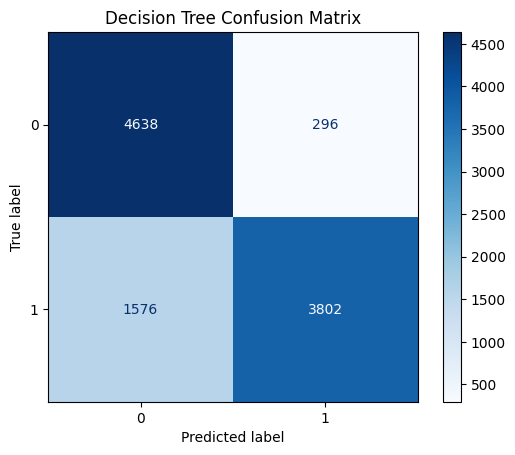

In [ ]:
# DECISION TREE

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Model parameters
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    min_samples_split=50,
    min_samples_leaf=20,
    max_depth=3,
    max_features="sqrt",
    class_weight="balanced",
    ccp_alpha=0.001,
    random_state=SEED
)

# Train
dt_model.fit(X_train_scaled, y_train)

# Predict
y_pred = dt_model.predict(X_test_scaled)

# Metrics
acc = round(accuracy_score(y_test, y_pred) * 100, 2)
prec = round(precision_score(y_test, y_pred) * 100, 2)
rec = round(recall_score(y_test, y_pred) * 100, 2)
f1 = round(f1_score(y_test, y_pred) * 100, 2)

print("Decision Tree Performance")
print(f"Accuracy  : {acc}%")
print(f"Precision : {prec}%")
print(f"Recall    : {rec}%")
print(f"F1 Score  : {f1}%")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Random Forest Model

Random Forest Performance
Accuracy  : 91.73%
Precision : 87.76%
Recall    : 97.77%
F1 Score  : 92.5%

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      4934
           1       0.88      0.98      0.92      5378

    accuracy                           0.92     10312
   macro avg       0.92      0.91      0.92     10312
weighted avg       0.92      0.92      0.92     10312



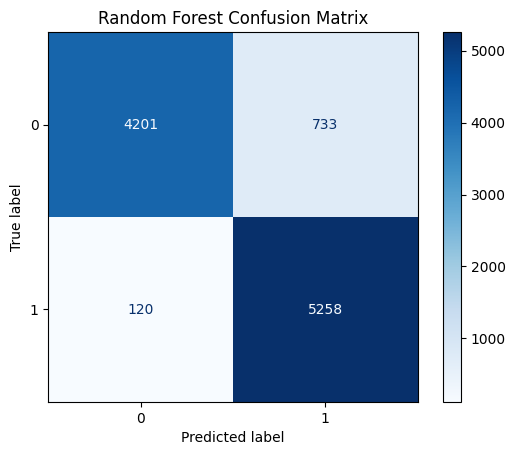

In [ ]:
#  RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Model with enhanced parameters
rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=3,
    min_samples_split=200,
    min_samples_leaf=50,
    max_features=1,
    bootstrap=False,
    n_jobs=-1,
    random_state=SEED
)

# Train
rf_model.fit(X_train_scaled, y_train)

# Predict
y_pred = rf_model.predict(X_test_scaled)

# Metrics
acc = round(accuracy_score(y_test, y_pred) * 100, 2)
prec = round(precision_score(y_test, y_pred) * 100, 2)
rec = round(recall_score(y_test, y_pred) * 100, 2)
f1 = round(f1_score(y_test, y_pred) * 100, 2)

print("Random Forest Performance")
print(f"Accuracy  : {acc}%")
print(f"Precision : {prec}%")
print(f"Recall    : {rec}%")
print(f"F1 Score  : {f1}%")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

## Deep Neural Network Model

Epoch 1/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7535 - loss: 0.5262 - val_accuracy: 0.9558 - val_loss: 0.2425
Epoch 2/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8918 - loss: 0.2826 - val_accuracy: 0.9599 - val_loss: 0.1704
Epoch 3/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9222 - loss: 0.2281 - val_accuracy: 0.9600 - val_loss: 0.1518
Epoch 4/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9348 - loss: 0.2009 - val_accuracy: 0.9596 - val_loss: 0.1425
Epoch 5/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9396 - loss: 0.1911 - val_accuracy: 0.9593 - val_loss: 0.1448
Epoch 6/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9411 - loss: 0.1863 - val_accuracy: 0.9606 - val_loss: 0.1374
Epoch 7/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9411 - loss: 0.1841 - val_accuracy: 0.9607 - val_loss: 0.1379
Epoch 8/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9429 - loss: 0.1798 -

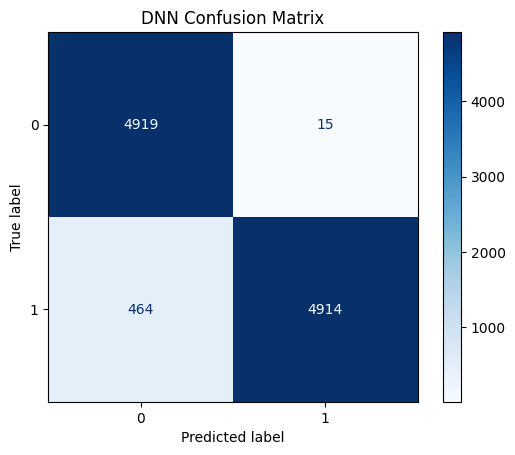

In [ ]:
# Deep Neural Network

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Reproducibility
tf.random.set_seed(SEED)

# Build DNN model
dnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.8),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.8),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

# Compile model
dnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train model
history = dnn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predictions
y_pred_prob = dnn_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Metrics
acc = round(accuracy_score(y_test, y_pred) * 100, 2)
prec = round(precision_score(y_test, y_pred) * 100, 2)
rec = round(recall_score(y_test, y_pred) * 100, 2)
f1 = round(f1_score(y_test, y_pred) * 100, 2)

print("DNN Performance Metrics")
print(f"Accuracy  : {acc}%")
print(f"Precision : {prec}%")
print(f"Recall    : {rec}%")
print(f"F1 Score  : {f1}%")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("DNN Confusion Matrix")
plt.show()

## 3-Layer MLP Model

Epoch 1/40
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.5270 - loss: 0.8709 - val_accuracy: 0.5292 - val_loss: 0.6805
Epoch 2/40
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5908 - loss: 0.6667 - val_accuracy: 0.5969 - val_loss: 0.6504
Epoch 3/40
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6571 - loss: 0.6181 - val_accuracy: 0.7184 - val_loss: 0.5472
Epoch 4/40
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7370 - loss: 0.5449 - val_accuracy: 0.9390 - val_loss: 0.3786
Epoch 5/40
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8014 - loss: 0.4645 - val_accuracy: 0.9581 - val_loss: 0.2797
Epoch 6/40
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8296 - loss: 0.4235 - val_accuracy: 0.9582 - val_loss: 0.2245
Epoch 7/40
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8495 - loss: 0.3939 - val_accuracy: 0.9598 - val_loss: 0.2016
Epoch 8/40
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8560 - loss: 0.3813 -

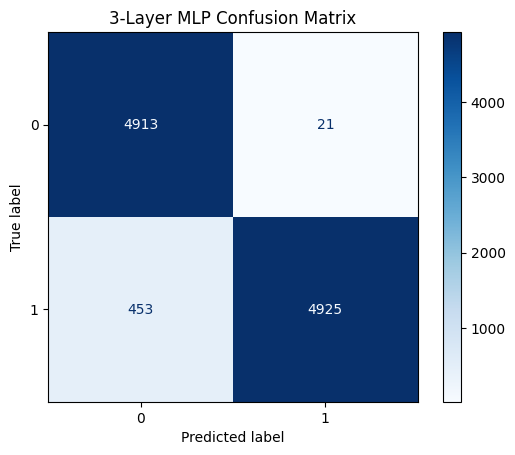

In [ ]:
# 3-Layer MLP Model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Reproducibility
tf.random.set_seed(SEED)

# Build 3-hidden-layer MLP
mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.9),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.9),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.9),

    Dense(1, activation='sigmoid')
])

# Compile model
mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train model
history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predictions
y_pred_prob = mlp_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Metrics
acc = round(accuracy_score(y_test, y_pred) * 100, 2)
prec = round(precision_score(y_test, y_pred) * 100, 2)
rec = round(recall_score(y_test, y_pred) * 100, 2)
f1 = round(f1_score(y_test, y_pred) * 100, 2)

print("3-Layer MLP Performance")
print(f"Accuracy  : {acc}%")
print(f"Precision : {prec}%")
print(f"Recall    : {rec}%")
print(f"F1 Score  : {f1}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("3-Layer MLP Confusion Matrix")
plt.show()

## FT-Transformer Model

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert to tensors
X_train_tt = torch.tensor(np.array(X_train_scaled), dtype=torch.float32).to(device)
X_test_tt = torch.tensor(np.array(X_test_scaled), dtype=torch.float32).to(device)

y_train_tt = torch.tensor(np.array(y_train), dtype=torch.long).to(device)
y_test_tt = torch.tensor(np.array(y_test), dtype=torch.long).to(device)

In [ ]:
# FT-Transformer Model

import torch
import torch.nn as nn

class FTTransformer(nn.Module):
    def __init__(self, num_features, d_token=64, n_heads=4, n_layers=3, dropout=0.2):
        super(FTTransformer, self).__init__()

        self.num_features = num_features
        self.d_token = d_token

        # one linear embedding per numerical feature
        self.feature_embed = nn.Linear(1, d_token)

        # CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))

        # transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token,
            nhead=n_heads,
            dim_feedforward=128,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        # output head
        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        # x shape: (batch, num_features)
        x = x.unsqueeze(-1)                  # (batch, num_features, 1)
        x = self.feature_embed(x)            # (batch, num_features, d_token)

        batch_size = x.size(0)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)   # (batch, 1, d_token)

        x = torch.cat([cls_tokens, x], dim=1)   # (batch, num_features+1, d_token)
        x = self.transformer(x)

        cls_output = x[:, 0]   # take CLS token
        out = self.head(cls_output)
        return out


model = FTTransformer(num_features=X_train_tt.shape[1])
print(model)

FTTransformer(
  (feature_embed): Linear(in_features=1, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=64, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Line

In [ ]:
# Training FT-Transformer

import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

X_train_t = X_train_tt.to(device)
y_train_t = y_train_tt.to(device)

X_test_t = X_test_tt.to(device)
y_test_t = y_test_tt.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0007, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.8)

patience = 10
best_loss = float("inf")
counter = 0

epochs = 50
batch_size = 256

for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_t.size(0))
    train_loss = 0

    for i in range(0, X_train_t.size(0), batch_size):
        idx = perm[i:i+batch_size]
        batch_x = X_train_t[idx]
        batch_y = y_train_t[idx]

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    scheduler.step()
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_t)
        val_loss = criterion(val_outputs, y_test_t).item()

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        best_model = model.state_dict()
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

model.load_state_dict(best_model)

Epoch 1/50, Train Loss: 75.2054, Val Loss: 0.3309
Epoch 2/50, Train Loss: 58.9829, Val Loss: 0.3696
Epoch 3/50, Train Loss: 60.1432, Val Loss: 0.3459
Epoch 4/50, Train Loss: 51.4342, Val Loss: 0.3227
Epoch 5/50, Train Loss: 53.0481, Val Loss: 0.3436
Epoch 6/50, Train Loss: 53.7470, Val Loss: 0.4306
Epoch 7/50, Train Loss: 48.7731, Val Loss: 0.3260
Epoch 8/50, Train Loss: 51.4770, Val Loss: 0.3324
Epoch 9/50, Train Loss: 50.0954, Val Loss: 0.3118
Epoch 10/50, Train Loss: 50.2513, Val Loss: 0.2493
Epoch 11/50, Train Loss: 43.9051, Val Loss: 0.2761
Epoch 12/50, Train Loss: 49.4950, Val Loss: 0.2948
Epoch 13/50, Train Loss: 40.4604, Val Loss: 0.3210
Epoch 14/50, Train Loss: 41.7857, Val Loss: 0.1865
Epoch 15/50, Train Loss: 28.4287, Val Loss: 0.1547
Epoch 16/50, Train Loss: 31.6260, Val Loss: 0.3378
Epoch 17/50, Train Loss: 30.2628, Val Loss: 0.1291
Epoch 18/50, Train Loss: 23.7372, Val Loss: 0.1888
Epoch 19/50, Train Loss: 25.0974, Val Loss: 0.1190
Epoch 20/50, Train Loss: 41.9741, Val Lo

<All keys matched successfully>


FT-TRANSFORMER PERFORMANCE

Accuracy  : 96.18%
Precision : 96.35%
Recall    : 96.18%
F1 Score  : 96.18%

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4934
           1       0.99      0.94      0.96      5378

    accuracy                           0.96     10312
   macro avg       0.96      0.96      0.96     10312
weighted avg       0.96      0.96      0.96     10312


CONFUSION MATRIX



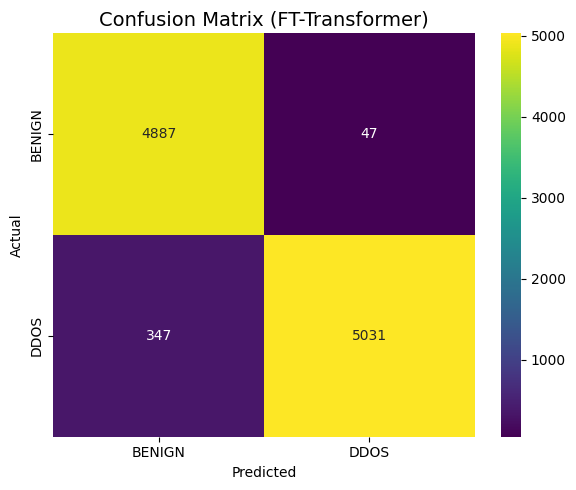

In [ ]:
# Evaluation FT-Transformer

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
model.eval()
model = model.to(device)

with torch.no_grad():
    outputs = model(X_test_t)
    _, y_pred = torch.max(outputs, 1)

y_pred = y_pred.cpu().numpy()
y_true = y_test_t.cpu().numpy()

accuracy = accuracy_score(y_true, y_pred) * 100
precision = precision_score(y_true, y_pred, average="weighted") * 100
recall = recall_score(y_true, y_pred, average="weighted") * 100
f1 = f1_score(y_true, y_pred, average="weighted") * 100

print("\nFT-TRANSFORMER PERFORMANCE\n")
print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"F1 Score  : {f1:.2f}%")
print("\nCLASSIFICATION REPORT\n")
print(classification_report(y_true, y_pred))

print("\nCONFUSION MATRIX\n")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=["BENIGN", "DDOS"],
            yticklabels=["BENIGN", "DDOS"])

plt.title("Confusion Matrix (FT-Transformer)", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Tabnet Model

In [ ]:
!pip install pytorch_tabnet


Early stopping occurred at epoch 12 with best_epoch = 10 and best_val_0_accuracy = 0.97682

TABNET PERFORMANCE

Accuracy  : 97.68%
Precision : 97.75%
Recall    : 97.68%
F1 Score  : 97.68%

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      4934
           1       0.99      0.96      0.98      5378

    accuracy                           0.98     10312
   macro avg       0.98      0.98      0.98     10312
weighted avg       0.98      0.98      0.98     10312


CONFUSION MATRIX

[[4908   26]
 [ 213 5165]]


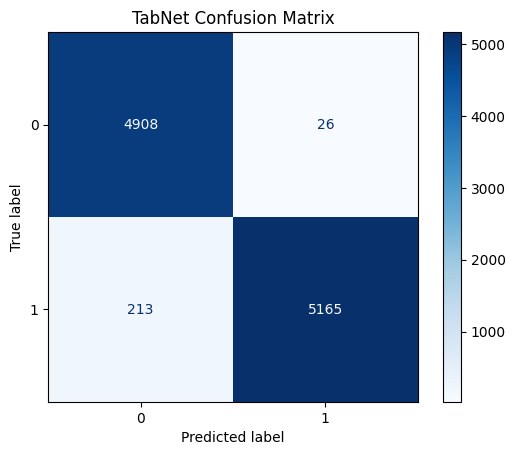

In [ ]:
import torch
import numpy as np
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Convert to numpy
X_train_tabnet = np.array(X_train_scaled, dtype=np.float32)
X_test_tabnet = np.array(X_test_scaled, dtype=np.float32)
y_train_tabnet = np.array(y_train)
y_test_tabnet = np.array(y_test)

# Simple TabNet model
tabnet_model = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=4,
    seed=SEED,
    verbose=0
)

# Train
tabnet_model.fit(
    X_train_tabnet,
    y_train_tabnet,
    eval_set=[(X_test_tabnet, y_test_tabnet)],
    eval_metric=["accuracy"],
    max_epochs=20,
    patience=2,
    batch_size=1024
)

# Predict
y_pred = tabnet_model.predict(X_test_tabnet)

# Metrics
accuracy = accuracy_score(y_test_tabnet, y_pred) * 100
precision = precision_score(y_test_tabnet, y_pred, average="weighted") * 100
recall = recall_score(y_test_tabnet, y_pred, average="weighted") * 100
f1 = f1_score(y_test_tabnet, y_pred, average="weighted") * 100

print("\nTABNET PERFORMANCE\n")
print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"F1 Score  : {f1:.2f}%")

print("\nCLASSIFICATION REPORT\n")
print(classification_report(y_test_tabnet, y_pred))

print("\nCONFUSION MATRIX\n")
cm = confusion_matrix(y_test_tabnet, y_pred)
print(cm)

# Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("TabNet Confusion Matrix")
plt.show()